# 3.6 softmax 回归的从零开始实现

本节不使用 `nn.Linear`、`CrossEntropyLoss` 和内置优化器，而是按照数学定义手写 softmax 回归的核心组件。这样可以看清一个多分类模型如何完成前向传播、计算损失、反向传播和参数更新。

原教材：[3.6 softmax 回归的从零开始实现](https://zh.d2l.ai/chapter_linear-networks/softmax-regression-scratch.html)

## 学习目标

1. 从零初始化 $784\times10$ 的权重和 10 个偏置；
2. 理解按行 softmax、广播和 `keepdim=True`；
3. 用高级索引实现交叉熵；
4. 实现分类精度、累加器和数据集评估；
5. 手写一个完整训练周期和小批量 SGD；
6. 理解朴素 softmax 与交叉熵的数值稳定性缺陷。

In [1]:
import sys  # 用于判断操作系统，以设置 DataLoader 工作进程数
from pathlib import Path  # 用于表示数据保存路径

import matplotlib.pyplot as plt  # 用于绘制训练曲线和预测图像
import torch  # 导入 PyTorch
import torchvision  # 提供 Fashion-MNIST 数据集
from torch.utils import data  # 提供 DataLoader
from torchvision import transforms  # 提供 ToTensor 图像变换

torch.manual_seed(42)  # 固定随机种子，使参数初始化更容易复现

def load_data_fashion_mnist(batch_size):  # 定义本节独立可运行的数据加载函数
    """下载 Fashion-MNIST，并返回训练和测试数据迭代器。"""
    transform = transforms.ToTensor()  # 将图像转换为 [0,1] 范围的浮点张量
    root = Path("../data")  # 指定数据缓存目录
    train_set = torchvision.datasets.FashionMNIST(  # 创建训练集
        root=root, train=True, transform=transform, download=True
    )
    test_set = torchvision.datasets.FashionMNIST(  # 创建测试集
        root=root, train=False, transform=transform, download=True
    )
    workers = 0 if sys.platform.startswith("win") else 4  # Windows Notebook 使用主进程读取
    train_loader = data.DataLoader(  # 训练集需要打乱
        train_set, batch_size=batch_size, shuffle=True, num_workers=workers
    )
    test_loader = data.DataLoader(  # 测试集保持固定顺序
        test_set, batch_size=batch_size, shuffle=False, num_workers=workers
    )
    return train_loader, test_loader  # 返回两个迭代器

batch_size = 256  # 与原教材一致，每批使用 256 个样本
train_iter, test_iter = load_data_fashion_mnist(batch_size)  # 首次运行会下载数据

## 3.6.1 初始化模型参数

一张 Fashion-MNIST 图像有 $28\times28=784$ 个像素。本节暂时忽略相邻像素的空间关系，将图像展平为 784 维向量。10 个类别对应 10 个输出，因此

$$
\mathbf W\in\mathbb R^{784\times10},\qquad
\mathbf b\in\mathbb R^{10}.
$$

一个大小为 $B$ 的批量展平后为 $\mathbf X\in\mathbb R^{B\times784}$，未归一化输出为

$$
\mathbf O=\mathbf X\mathbf W+\mathbf b\in\mathbb R^{B\times10}.
$$

偏置在批量维上通过广播加到每一行。

In [2]:
num_inputs = 28 * 28  # 每张图像展平后有 784 个输入特征
num_outputs = 10  # Fashion-MNIST 有 10 个类别

W = torch.normal(  # 从正态分布中初始化权重
    mean=0.0,  # 权重均值为 0
    std=0.01,  # 使用较小标准差，避免初始输出过大
    size=(num_inputs, num_outputs),  # 权重形状为 [784, 10]
    requires_grad=True,  # 告诉自动微分系统需要计算 W 的梯度
)
b = torch.zeros(num_outputs, requires_grad=True)  # 偏置初始化为 10 个零并跟踪梯度

print("W 形状:", W.shape)  # torch.Size([784, 10])
print("b 形状:", b.shape)  # torch.Size([10])

W 形状: torch.Size([784, 10])
b 形状: torch.Size([10])


## 3.6.2 定义 softmax 操作

对批量中第 $i$ 个样本、第 $j$ 个类别的 logit $X_{ij}$，softmax 定义为

$$
\operatorname{softmax}(\mathbf X)_{ij}
=\frac{\exp(X_{ij})}{\sum_k\exp(X_{ik})}.
$$

计算步骤是：逐元素求指数、每行求和、每行除以自己的和。每一行对应一个样本，所以每行结果都是概率分布。

In [3]:
sum_example = torch.tensor([[1.0, 2.0, 3.0],  # 创建一个 2 行 3 列矩阵
                            [4.0, 5.0, 6.0]])

print("沿 dim=0 求和:", sum_example.sum(dim=0, keepdim=True))  # 压缩行，结果形状 [1,3]
print("沿 dim=1 求和:\n", sum_example.sum(dim=1, keepdim=True))  # 压缩列，结果形状 [2,1]

# keepdim=True 保留被求和的维度，得到 [2,1]，便于与 [2,3] 矩阵进行广播除法

沿 dim=0 求和: tensor([[5., 7., 9.]])
沿 dim=1 求和:
 tensor([[ 6.],
        [15.]])


In [4]:
def softmax(X):  # 按数学定义实现 softmax
    X_exp = torch.exp(X)  # 对每个 logit 求指数，使结果为正数
    partition = X_exp.sum(dim=1, keepdim=True)  # 每行求和，得到每个样本的配分函数
    return X_exp / partition  # 利用广播，让每行除以自己的配分函数

softmax_input = torch.normal(0, 1, size=(2, 5))  # 模拟 2 个样本、5 个类别的 logits
softmax_output = softmax(softmax_input)  # 转换为类别概率
print("概率:\n", softmax_output)
print("每行概率和:", softmax_output.sum(dim=1))  # 每行应接近 1
print("所有概率非负:", bool((softmax_output >= 0).all()))  # 应为 True

概率:
 tensor([[0.3377, 0.0588, 0.1388, 0.3187, 0.1460],
        [0.3305, 0.2752, 0.0818, 0.1630, 0.1495]])
每行概率和: tensor([1., 1.])
所有概率非负: True


## 3.6.3 定义模型

`X.reshape(-1, W.shape[0])` 把任意批量的图像变成 `[批量大小, 784]`。`-1` 表示让 PyTorch 根据总元素数自动推断该维长度。模型随后计算矩阵乘法、加偏置和 softmax。

In [5]:
def net(X):  # 定义从图像到类别概率的完整前向传播
    X_flat = X.reshape(-1, W.shape[0])  # 将 [B,1,28,28] 展平为 [B,784]
    logits = torch.matmul(X_flat, W) + b  # 计算 [B,784]@[784,10]+[10] -> [B,10]
    return softmax(logits)  # 将 logits 转换成每行和为 1 的概率

demo_images = torch.rand(4, 1, 28, 28)  # 构造 4 张合成图像用于形状测试
demo_probabilities = net(demo_images)  # 执行前向传播
print("模型输出形状:", demo_probabilities.shape)  # 应为 [4,10]
print("概率和:", demo_probabilities.sum(dim=1))  # 每个样本的概率和应为 1

模型输出形状: torch.Size([4, 10])
概率和: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


## 3.6.4 定义损失函数

若第 $i$ 个样本真实类别为 $y_i$，交叉熵损失是

$$
l_i=-\log \hat y_{i,y_i}.
$$

我们只需从每一行取出真实类别对应的概率。`y_hat[range(len(y_hat)), y]` 使用两个索引数组配对选取元素：第 0 行取第 `y[0]` 列，第 1 行取第 `y[1]` 列，以此类推。这叫**高级索引**，可避免缓慢的 Python 逐样本循环。

In [6]:
def cross_entropy(y_hat, y):  # 实现逐样本交叉熵
    row_indices = torch.arange(len(y_hat), device=y_hat.device)  # 创建行索引 [0,1,...,B-1]
    true_class_probabilities = y_hat[row_indices, y]  # 取出每个样本真实类别的预测概率
    return -torch.log(true_class_probabilities)  # 概率取负对数，返回形状 [B]

example_y_hat = torch.tensor([[0.1, 0.3, 0.6],  # 第一个样本的三类概率
                              [0.3, 0.2, 0.5]])  # 第二个样本的三类概率
example_y = torch.tensor([0, 2])  # 真实类别分别为第 0 类和第 2 类
print("真实类别概率:", example_y_hat[[0, 1], example_y])  # 应为 [0.1,0.5]
print("逐样本损失:", cross_entropy(example_y_hat, example_y))  # 约为 [2.3026,0.6931]

真实类别概率: tensor([0.1000, 0.5000])
逐样本损失: tensor([2.3026, 0.6931])


## 3.6.5 分类精度

预测时取每行最大概率的类别索引。准确率是正确预测数除以样本总数。`argmax` 和相等比较几乎处处不可导，所以准确率适合评估，不适合作为梯度训练的损失函数。

In [7]:
def accuracy(y_hat, y):  # 返回一个批量中预测正确的样本数
    if y_hat.ndim > 1 and y_hat.shape[1] > 1:  # 二维多分类输出需要先转成类别索引
        y_hat = y_hat.argmax(dim=1)  # 对每行取最大值所在列
    comparison = y_hat.to(y.dtype) == y  # 统一数据类型后逐元素比较
    return float(comparison.to(torch.float32).sum())  # True/False 转 1/0 后求和

class Accumulator:  # 定义可以同时累加多个数值的工具类
    """在 n 个变量上累加。"""
    def __init__(self, n):  # 构造函数在创建对象时自动执行
        self.data = [0.0] * n  # 创建包含 n 个 0.0 的列表

    def add(self, *args):  # *args 接收任意数量的位置参数
        self.data = [a + float(b) for a, b in zip(self.data, args)]  # 对应位置相加

    def reset(self):  # 将所有累计量清零
        self.data = [0.0] * len(self.data)

    def __getitem__(self, index):  # 允许使用 accumulator[index] 读取累计值
        return self.data[index]

print("示例准确率:", accuracy(example_y_hat, example_y) / len(example_y))  # 1/2=0.5

示例准确率: 0.5


In [8]:
def evaluate_accuracy(net, data_iter):  # 在完整数据集上计算准确率
    metric = Accumulator(2)  # 分别累计正确数和样本总数
    with torch.no_grad():  # 评估不需要构建梯度计算图，可节省内存和计算
        for X, y in data_iter:  # 逐批读取数据
            metric.add(accuracy(net(X), y), y.numel())  # 累计正确数与标签元素数
    return metric[0] / metric[1]  # 正确数除以总数

# 随机初始化模型在 10 类问题上的测试精度通常接近随机猜测水平 0.1
print("训练前测试精度:", evaluate_accuracy(net, test_iter))

训练前测试精度: 0.1053


## 3.6.6 训练

每个小批量执行六步：前向传播、计算损失、反向传播、更新参数、清空梯度、累计指标。

这里让 `cross_entropy` 返回每个样本的损失，并使用 `loss.sum().backward()`。因此手写 SGD 更新时要除以当前批量大小，使梯度对应批量平均损失。最后一批可能不足 256，必须使用 `X.shape[0]`，不能固定除以 256。

In [9]:
def sgd(params, learning_rate, current_batch_size):  # 手写小批量随机梯度下降
    with torch.no_grad():  # 参数更新本身不应被自动微分记录
        for param in params:  # 依次更新 W 和 b
            param -= learning_rate * param.grad / current_batch_size  # 沿负梯度方向移动
            param.grad.zero_()  # 清空梯度；PyTorch 默认会累加梯度

def train_epoch_ch3(net, train_iter, loss, updater):  # 训练一个完整迭代周期
    metric = Accumulator(3)  # 累计损失总和、正确预测数、样本数

    for X, y in train_iter:  # 遍历所有训练批量
        y_hat = net(X)  # 前向传播，得到类别概率
        batch_loss = loss(y_hat, y)  # 得到当前批量每个样本的损失
        batch_loss.sum().backward()  # 对损失总和执行反向传播
        updater(X.shape[0])  # 使用当前批量的真实大小更新参数
        metric.add(batch_loss.sum().item(), accuracy(y_hat, y), y.numel())  # 累计指标

    return metric[0] / metric[2], metric[1] / metric[2]  # 返回平均损失和训练准确率

In [10]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  # 完整训练函数
    history = {"train_loss": [], "train_acc": [], "test_acc": []}  # 保存每轮指标

    for epoch in range(num_epochs):  # epoch 从 0 开始循环 num_epochs 次
        train_loss, train_acc = train_epoch_ch3(net, train_iter, loss, updater)  # 训练一轮
        test_acc = evaluate_accuracy(net, test_iter)  # 在测试集上评估
        history["train_loss"].append(train_loss)  # 保存训练损失
        history["train_acc"].append(train_acc)  # 保存训练准确率
        history["test_acc"].append(test_acc)  # 保存测试准确率
        print(  # 输出当前轮结果
            f"epoch {epoch + 1:2d}: loss={train_loss:.4f}, "
            f"train acc={train_acc:.4f}, test acc={test_acc:.4f}"
        )

    epochs = range(1, num_epochs + 1)  # 创建横轴 1～num_epochs
    plt.plot(epochs, history["train_loss"], label="train loss")  # 绘制损失
    plt.plot(epochs, history["train_acc"], label="train acc")  # 绘制训练准确率
    plt.plot(epochs, history["test_acc"], label="test acc")  # 绘制测试准确率
    plt.xlabel("epoch")  # 设置横轴名称
    plt.grid(alpha=0.3)  # 添加浅色网格
    plt.legend()  # 显示图例
    plt.show()  # 显示训练曲线
    return history  # 返回历史记录，便于后续分析

epoch  1: loss=0.7885, train acc=0.7441, test acc=0.7806
epoch  2: loss=0.5711, train acc=0.8124, test acc=0.8079
epoch  3: loss=0.5252, train acc=0.8267, test acc=0.8161
epoch  4: loss=0.5016, train acc=0.8317, test acc=0.8210
epoch  5: loss=0.4847, train acc=0.8372, test acc=0.8206
epoch  6: loss=0.4737, train acc=0.8408, test acc=0.8226
epoch  7: loss=0.4650, train acc=0.8426, test acc=0.8290
epoch  8: loss=0.4592, train acc=0.8438, test acc=0.8103
epoch  9: loss=0.4520, train acc=0.8469, test acc=0.8334
epoch 10: loss=0.4476, train acc=0.8478, test acc=0.8349


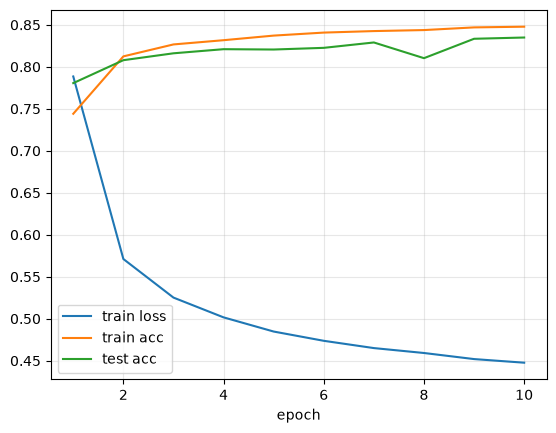

In [11]:
learning_rate = 0.1  # 设置手写 SGD 的学习率
num_epochs = 10  # 与原教材一致，训练 10 轮

def updater(current_batch_size):  # 将固定参数和学习率封装为更新函数
    sgd([W, b], learning_rate, current_batch_size)  # 更新 W、b 并清空梯度

training_history = train_ch3(  # 开始训练
    net, train_iter, test_iter, cross_entropy, num_epochs, updater
)

## 3.6.7 预测

训练完成后，取测试集中的若干图像，对比真实类别和预测类别。标题第一行是真实标签，第二行是预测标签。

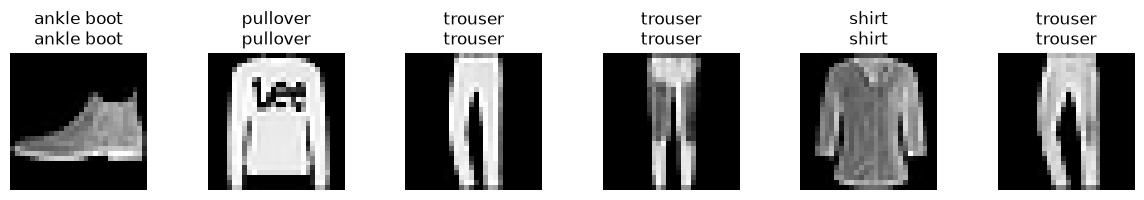

In [12]:
fashion_labels = [  # 数字类别到文本类别的映射表
    "t-shirt", "trouser", "pullover", "dress", "coat",
    "sandal", "shirt", "sneaker", "bag", "ankle boot",
]

def predict_ch3(net, test_iter, n=6):  # 显示前 n 个样本的预测结果
    X, y = next(iter(test_iter))  # 取得测试集第一个批量
    with torch.no_grad():  # 预测不需要梯度
        predicted_indices = net(X).argmax(dim=1)  # 取最大概率类别
    true_names = [fashion_labels[int(index)] for index in y[:n]]  # 转换真实标签
    predicted_names = [fashion_labels[int(index)] for index in predicted_indices[:n]]  # 转换预测
    titles = [f"{true}\n{pred}" for true, pred in zip(true_names, predicted_names)]  # 组合标题

    _, axes = plt.subplots(1, n, figsize=(2 * n, 2))  # 创建一行 n 列子图
    for axis, image, title in zip(axes, X[:n], titles):  # 同时遍历图像和标题
        axis.imshow(image.squeeze(0), cmap="gray")  # 去掉灰度通道维并显示
        axis.set_title(title)  # 设置真实/预测标题
        axis.axis("off")  # 隐藏坐标轴
    plt.tight_layout()  # 调整子图间距
    plt.show()  # 显示结果

predict_ch3(net, test_iter)  # 调用预测函数

## 本节知识与代码梳理

$$
X:[B,1,28,28]
\xrightarrow{\text{reshape}}[B,784]
\xrightarrow{XW+b}\text{logits}:[B,10]
\xrightarrow{\text{softmax}}\hat Y:[B,10]
\xrightarrow{-\log\hat Y_{i,y_i}}l:[B].
$$

随后 `l.sum().backward()` 计算梯度，`sgd` 更新参数并清空梯度。`accuracy` 负责单批正确数，`Accumulator` 跨批累加，`evaluate_accuracy` 负责完整数据集评估，`train_ch3` 组织多个迭代周期。

从零实现的价值不是替代框架，而是理解框架在替我们完成什么。

## 3.6.8 小结

- softmax 回归可以训练多分类模型；
- 图像被展平后通过线性变换得到 10 个 logits，再转为概率；
- 交叉熵只取真实类别的预测概率并计算负对数；
- 分类精度不可导，通常只用于评估；
- 训练分类模型与训练线性回归具有相同骨架：数据、模型、损失、梯度和优化；
- 按定义直接实现 softmax 和对数可能产生数值稳定性问题。

## 3.6.9 练习

1. 按数学定义实现的 `softmax` 可能导致什么问题？尝试计算 $\exp(50)$。
2. 按定义实现的 `cross_entropy` 可能有什么问题？考虑对数的定义域。
3. 给出同时解决上述两个问题的方法。
4. 返回概率最大的类别总是最优决策吗？医疗诊断中可以直接这样做吗？
5. 使用 softmax 回归预测下一个单词时，候选词数量过多会带来哪些问题？

## 3.6.10 练习题参考答案

### 练习 1

`exp` 增长极快。$\exp(50)\approx5.18\times10^{21}$；对于 float32，`exp(89)` 左右就可能上溢为 `inf`。若 softmax 分子和分母出现 `inf`，`inf/inf` 会得到 `nan`。非常负的 logits 又可能指数下溢为 0。

### 练习 2

`cross_entropy` 计算 `-log(p)`，要求 $p>0$。若真实类别概率因为下溢或舍入成为 0，则 `log(0)=-inf`，损失变为 `inf`，后续梯度可能出现 `nan`。简单地给概率加一个很小的 $\epsilon$ 能避免 `log(0)`，但会改变目标函数且不能彻底解决 softmax 上溢。

### 练习 3

先利用 softmax 的平移不变性，从每行 logits 中减去最大值，可避免指数上溢。更完整的方法是不显式计算概率，而是直接从 logits 计算

$$
l_i=\log\sum_j\exp(o_{ij})-o_{i,y_i}.
$$

`torch.logsumexp` 内部使用稳定的 LogSumExp 技巧。实际项目应优先使用接收 logits 的 `torch.nn.CrossEntropyLoss`。

In [13]:
def stable_cross_entropy_from_logits(logits, y):  # 直接从 logits 计算稳定交叉熵
    row_indices = torch.arange(len(logits), device=logits.device)  # 创建样本行索引
    log_partition = torch.logsumexp(logits, dim=1)  # 稳定计算 log(sum(exp(logits)))
    true_logits = logits[row_indices, y]  # 取出真实类别对应的 logit
    return log_partition - true_logits  # 返回每个样本的交叉熵

large_logits = torch.tensor([[1000.0, 999.0, -1000.0]])  # 构造会使朴素 exp 上溢的输入
large_label = torch.tensor([0])  # 真实类别为第 0 类
print("朴素 softmax:", softmax(large_logits))  # 可能包含 nan
print("稳定交叉熵:", stable_cross_entropy_from_logits(large_logits, large_label))  # 有限结果

朴素 softmax: tensor([[nan, nan, 0.]])
稳定交叉熵: tensor([0.3132])


### 练习 4

概率最大类别只在“所有错误代价相同、必须输出一个类别”的 0-1 损失下是贝叶斯最优决策。医疗诊断通常不满足此前提：漏诊严重疾病的代价可能远高于误报。

更合理的决策是最小化期望代价：

$$
a^*=\arg\min_a\sum_y C(a,y)P(y\mid x),
$$

其中 $C(a,y)$ 是采取决策 $a$、真实状态为 $y$ 的代价。实践中还会调整阈值、优先保证灵敏度、允许“需要进一步检查”或输出多个候选，并结合概率校准和医生判断。

### 练习 5

若词表大小为 $V$、隐藏表示维度为 $d$，普通输出层需要 $dV$ 个权重；每个样本还要计算 $V$ 个 logits 和 softmax 分母。大词表会造成：

- 参数与显存占用巨大；
- 每步矩阵乘法和归一化为 $O(V)$，训练和推理变慢；
- 低频词样本少，参数难以充分学习；
- 每次都计算大量几乎不可能的类别，效率低；
- 未登录词和词形变化使固定词表更困难。

常见缓解方法包括子词切分、分层 softmax、采样 softmax、负采样或噪声对比估计，以及候选词筛选。